<a href="https://colab.research.google.com/github/vladi452/act_2/blob/main/notebook/Actividad_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![](https://upload.wikimedia.org/wikipedia/commons/4/42/UNIR_Horizontal_Logo.png)
# __ACTIVIDAD 2__
## ASIGNATURA: BASES DE DATOS PARA DATOS MASIVOS
DOCENTE : BARBARO FERRO CASTRO


ESTUDIANTES:
* SUSANA ALFARO LIRA
* JOSE CHABLÉ DE LA CRUZ
* JAFETH LEYVA REYNA
* WANDER PAYANO LINARES
* LUIS VEGA CABALLERO

## __Objetivo de la actividad__
Esta actividad, nos permitió utilizar funcionalidades de las bases de datos NoSQL, en concreto MongoDB y Neo4J.
A lo largo de esta actividad, realizamos una serie de ejercicios donde monitorizamos la actividad de la base de datos de MongoDB y diseñamos un grafo que nos permitió visualizar un conjunto de datos extraidos en Neo4J.

## **Pautas de elaboración**

Para esta actividad, se procesaron diferentes ficheros sobre MongoDb mientras monitorizamos la activida de la base de datos. Finalmente, con un conjunto de datos extraídos de MongoDB, obtuvimos un grafo de que muestra determinadas relaciones entre estos. Para la realización de la actividad grupal se desarrollaron los apartados enunciados a continuación.

## **I. Inicio de la monitorización en MongoDB**

__a.__  Se solicita abrir en una consola, diferente al mongoshell, el `mongostat --discover`.\
__b.__ En una consola distinta, se solicita visualizar el top de las operaciones contra la base de datos, utilizando la instrucción `mongotop 5`, donde 5 es el tiempo en segundo que debe de refrescar la visualización.\
__c.__ Además se solicita tener estas consolas siempre activas y visibles mientras se realizan los puntos siguientes, interpretando sus salidas y describiendo brevemente que muestran cuando se ejecutan dichas instrucciones. Para ello se utilizarán capturas de pantalla para ilutrar nuestras respuestas.

__RESPUESTA AL PUNTO A__

__Mongostat__ es una herramienta de monitorización en tiempo real que muestra, por defecto cada un segundo, las estadisticas del servidor.
En la siguiente imagen se observa que el `mongostat` entrega datos sobre:
1. **host** ➡ indica el servidor o instancia de MongoDB que se esta monitorizando.
2. **insert** ➡ indica el número de operaciones de inserción `(insert)` por segundo.
3. **query** ➡ indica el número de consultas `(find)`.
4. **update** ➡ muestra el número de actualizaciones por segundo `(update)`
5. **delete** ➡ número de documentos eliminados `(delete)`
6. **getmore** ➡ muestra las operaciones de `(getMore)` por segundo, se utilizan cuando una consulta devuelve muchos documentos y MongoDB los envía en lotes, es común cuando se utilizan cursores grandes.
7. **command** ➡ muestra la cantidad de comandos internos como `ping`, `aggregate`, `count`, `listColections`
8. **dirty** ➡ porcentaje de memoria sucia, es decir datos modificados en RAM que no se han escrito en el disco, valores bajos son normales.
9. **flushes** ➡ número de operaciones de escritura a disco (flush), indica cuándo los datos en memoria persisten
10. **vsize**  ➡ cantidad de memoria virtual asignada a MongoDB
11. **res** ➡ memoria realmente usada en RAM por MongoDB
12. **qrw** ➡ número de operaciones en cola (queued readers/writers)
13. **arw** ➡ Número de operaciones activas en ejecución (active readers/writers)
14. **net_in** ➡ cantidad de datos recibidos por MongoDb desde la red, se muestra en bytes `b` o en kilobytes `k`
15. **net_out** ➡ cantidad de datos enviados por MongoDB a la red, esto refleja respuestas a clientes.
16. **conn** ➡ número de conexiones activas al servidor MongoDB, esto incluye el mongosh, mongostat, entre otros.
17. y finalmente **time** ➡ fecha y hora exacta en la que se capturo la estadísitica.


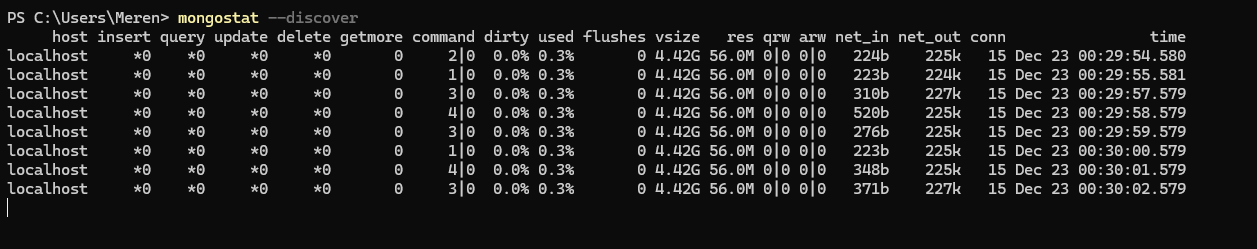



**RESPUESTA AL PUNTO B**

`Mongotop` permite monitorear en tiempo real, en este caso en particular cada 5 segundos, el tiempo que dedica MongoDB a operaciones de lectura (como por ejemplo `find`, `aggregate`) y escritura (por ejemplo `insert`, `update`, `delete)` **por colección**.

Al decir cero, quiere decir que el servidor esta en reposo, que las colecciones están, pero no tienen un uso activo en el momento de la observación, y es con esta herramienta que se puede observar si hay cuellos de botella o cargas.

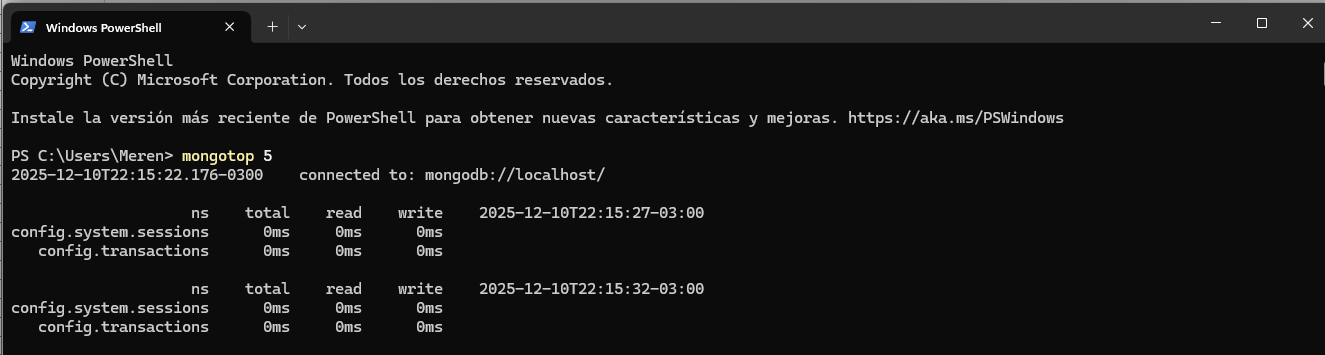

**RESPUESTA A PUNTO C**

En esta etapa se mantuvieron las consolas siempre activas, mientras se realizaron los puntos del d al f, que se enunciaran en el siguiente bloque.

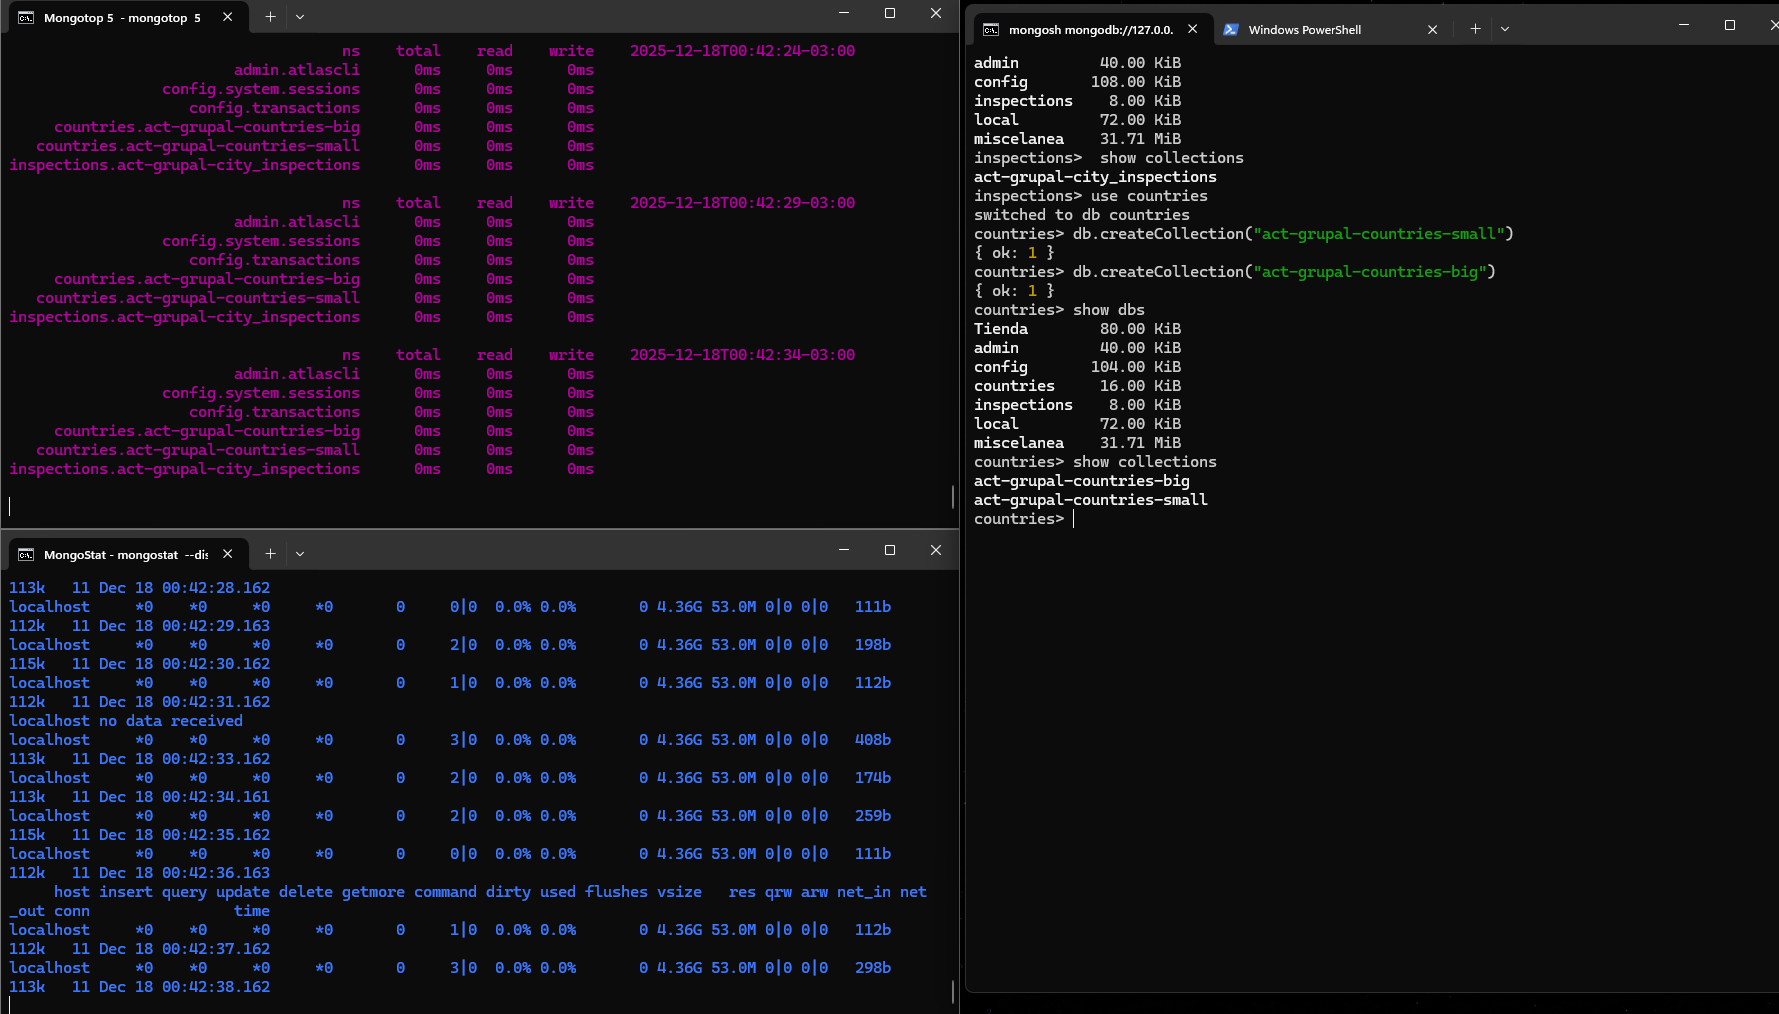

## **II. IMPORTAR LA BASE DE DATOS**

Luego de iniciar el proceso de monitorización de la base de datos (mongostat) y de las colecciones (mongotop) se solicita desarrollar los siguientes puntos:

**d.** Crear la base de datos `inspections` y dentro de ella la colección que corresponde a los datos del fichero *act-grupal-city_inspections.json*.\
**e.** Crear la base de datos `countries` y dentro de ella dos colecciones que corresponden a los ficheros *act-grupal-countries-small.json* y *act-grupal-countries-big.json*.

Además de estos puntos se solicita desarrollar un reto:
> **RETO**: propón una única instrucción en el punto a y en el b. En el b amplía tu visión y saca provecho a las bondades de Mongoshell.





**RESPUESTA PARA PUNTO D**

Para crear la base de datos se utiliza el comando `use`.


Para importar los datos se utilizó la siguiente sintaxis:

>`mongoimport --verbose --db inspections --collection  city_inspections  --file "C:\Unir_1\Actividad 2\act-grupal-city_inspections.json"`

Con esto se importaron 81047 documentos a la colección llamada `city_inspections`
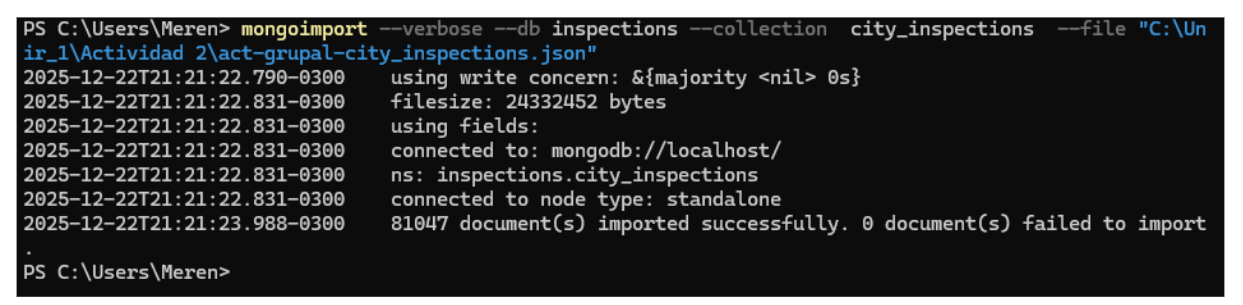

Para corroborar que la colección se importo correctamente se utilizo el comando `show collections`en mongoshell
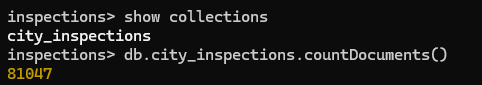

Al igual que en los datos de la importación la colección posee 81047 documentos.

Por otro lado, al observar el mongostat, se ve movimientos en los puntos de insert, donde hizo dos inserciones: la primera de 10468 documentos y la segunda de 70611, aumentando el uso de ram de 144M a 196M y el internet de entrada de 112 b a un máximo de 19.4m.

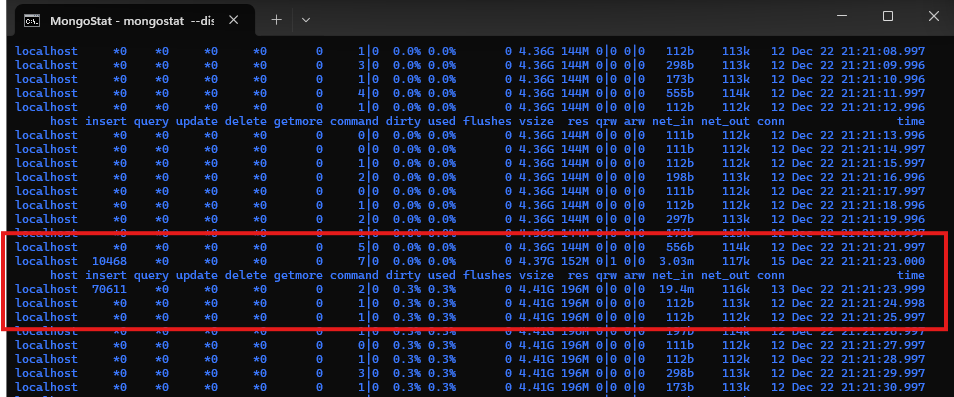

**RESPUESTA A PUNTO E**

Se crea la base de datos countries y las colecciones solicitadas, luego con mongoimport se importarán las colecciones solicitadas, una por vez.

*Script*
```
# SE IMPORTA LA PRIMERA COLECCIÓN DE COUNTRIES_SMALL
mongoimport --verbose --db countries --collection  countries_small  --file "C:\Unir_1\Actividad 2\act-grupal-countries-small.json"
```
.
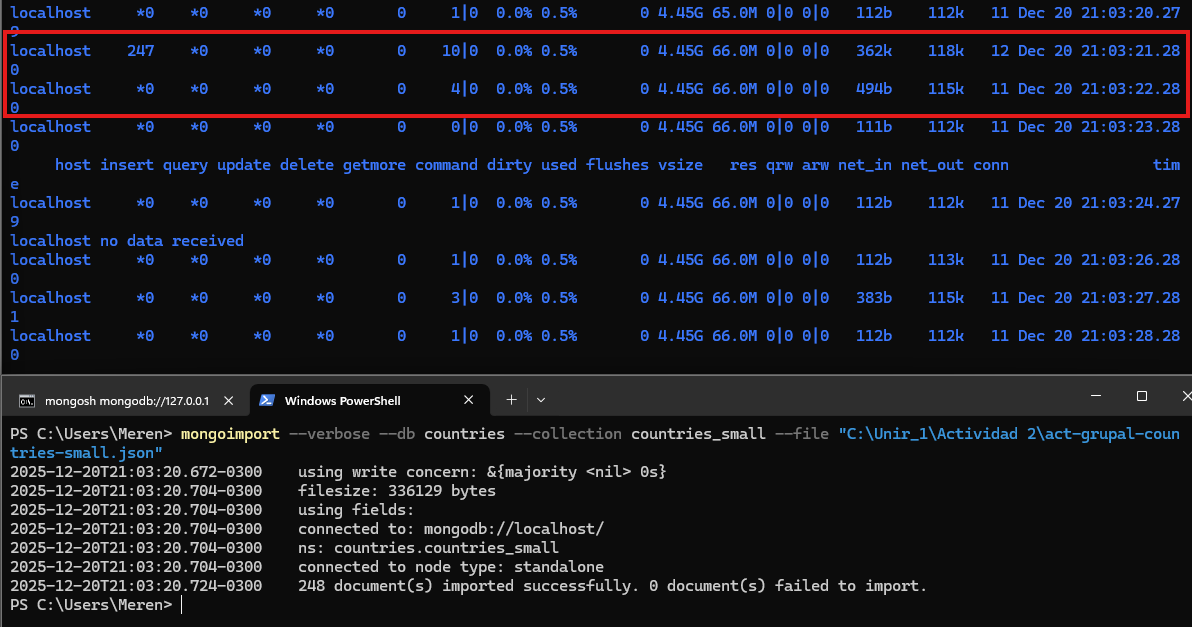

\


```
# SE IMPORTA LA SEGUNDA COLECCIÓN DE COUNTRIES_BIG
mongoimport --verbose --db countries --collection  countries_big  --file "C:\Unir_1\Actividad 2\act-grupal-countries-big.json"
 ```
\

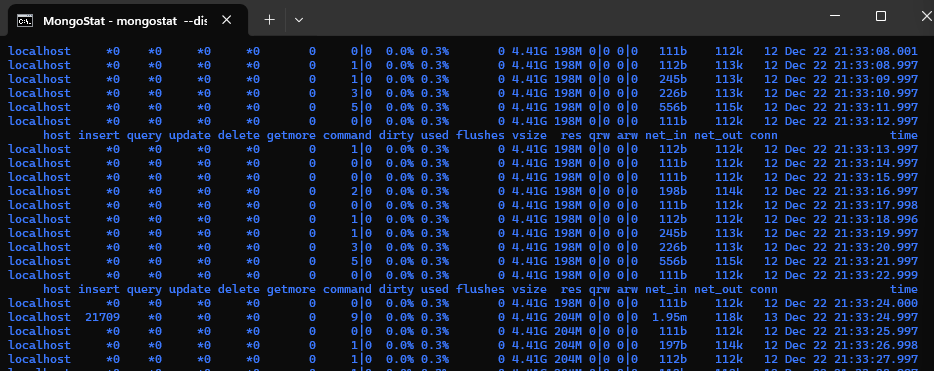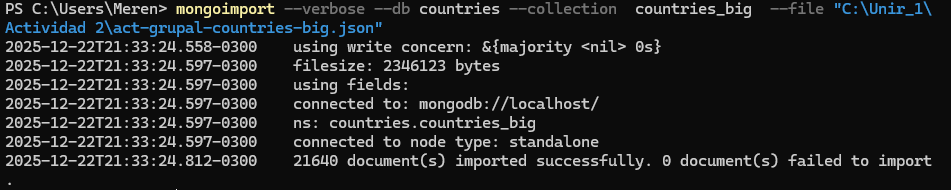

Al observar la ventana de mongotop, no se encontraron uso de datos de escritura:

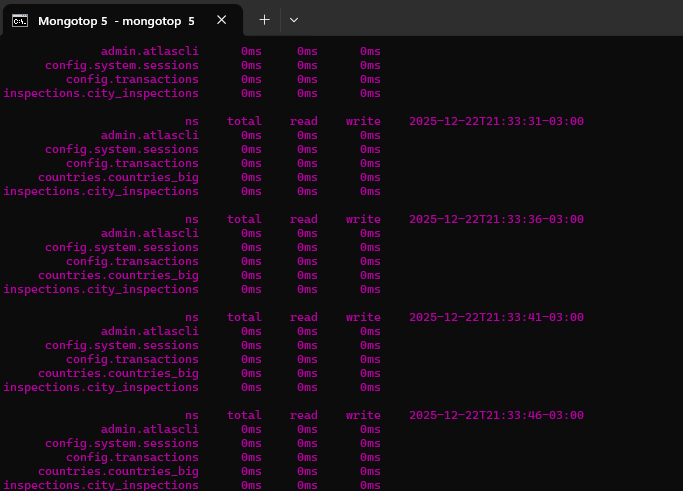


**RESPUESTA AL RETO**


Con respecto al reto, las herramientas de mongostat y mongotop, no son ejecutables desde el shell de Mongo, por lo que se deben abrir si o si en teminales separadas. Para ello se propone la solución de crear un archivo bat con la siguiente estructura en un block de notas:  


```
@echo off color 0B
echo ===================================================  
echo INICIANDO SERVICIO DE MONITOREO DE MONGO DB  
echo ===================================================  
echo.
start "MongoStat" cmd /k "color 09 & mongostat --discover"
start "Mongotop 5 " cmd /k "color 0D & mongotop 5"

echo ***Para cerrar las ventanas presione ctrl c pause***
```

Sin embargo, las instrucciones dadas por la actividad, utilizan el tiempo de muestreo por defecto del `mongostat` (de 1 segundo), por lo que se podría utilizar  `mongostat 5 –discover`, para que la tasa de muestreo sea cada 5 segundos, al igual que mongotop 5 y de esta manera se encuentren sincronizados. Lo interesante del `mongostat -- discover`, es que nos conectaría a los diferentes nodos o réplicas de los servidores, para observar cómo están funcionando y si es que existen o no problemas de atasco de datos o "cuellos de botella" en el servidor por exceso de uso. Al utilizar estas herramientas, nos permiten ver en "tiempo real" lo que ocurre en el servidor. Por otro lado, mongotop, nos permite monitorizar las lecturas y escrituras que se están realizando en las distintas colecciones y de la base de datos.  

---
**#OJO** ⏰
---
Falta el reto del punto b, de cómo monitorizar desde el shell, que en este caso sería una fotografía del momento, y no una seríe de capturas de estado como lo hacen las otras herramientas de mongostat y mongotop.


## **III. EXPORTAR LA BASE DE DATOS**

En este apartado se solicitan realizar dos acciones:\
**a.** Para restaurar una base de datos, debéis indicar la ruta del directorio dump donde se almacenan los ficheros de la base de datos (json y bson).



> dump  
people  
--people.bson\
--people.metadata.json

**b**. Descomprimir el fichero act-grupal-people.zip y ubicar los ficheros en la estructura de directorios indicada en el paso anterior.



####**RESPUESTA PARA LA EXPORTACIÓN DE DATOS PUNTOS A Y B**
Nuestra colección la nombramos city_inspections, por lo que se ocupó el siguiente script para realizar la exportación:
>**`mongoexport --verbose --collection city_inspections --db inspections --out inspections.json`**

Agregamos `"--verbose"` para que la consola mostrará el trabajo realizado, lo que nos permite rastrear los tiempos en que debemos observar en mongostat y mongotop para detectar posibles cambios.

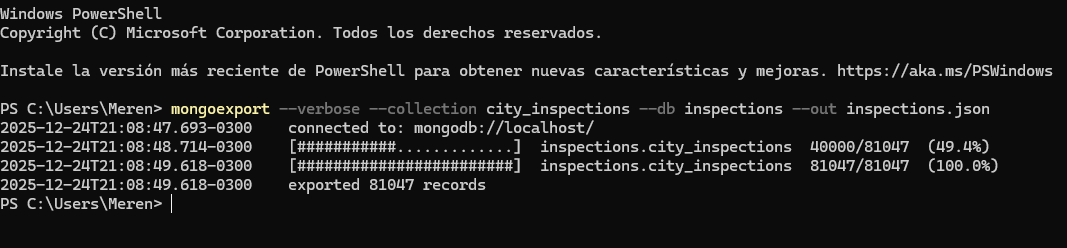\

Con respecto a las herramientas de monitoreo, el `mongotop`  detecto entre las bases de datos a inspections.city_inspections, pero no marco uso. Por su parto `mongostat` detecto una variación en el uso de memoria (rem) y las cantidades de datos recibidos y enviados (net_in y net_out), además del aumento de conexiones de 11 a 14.

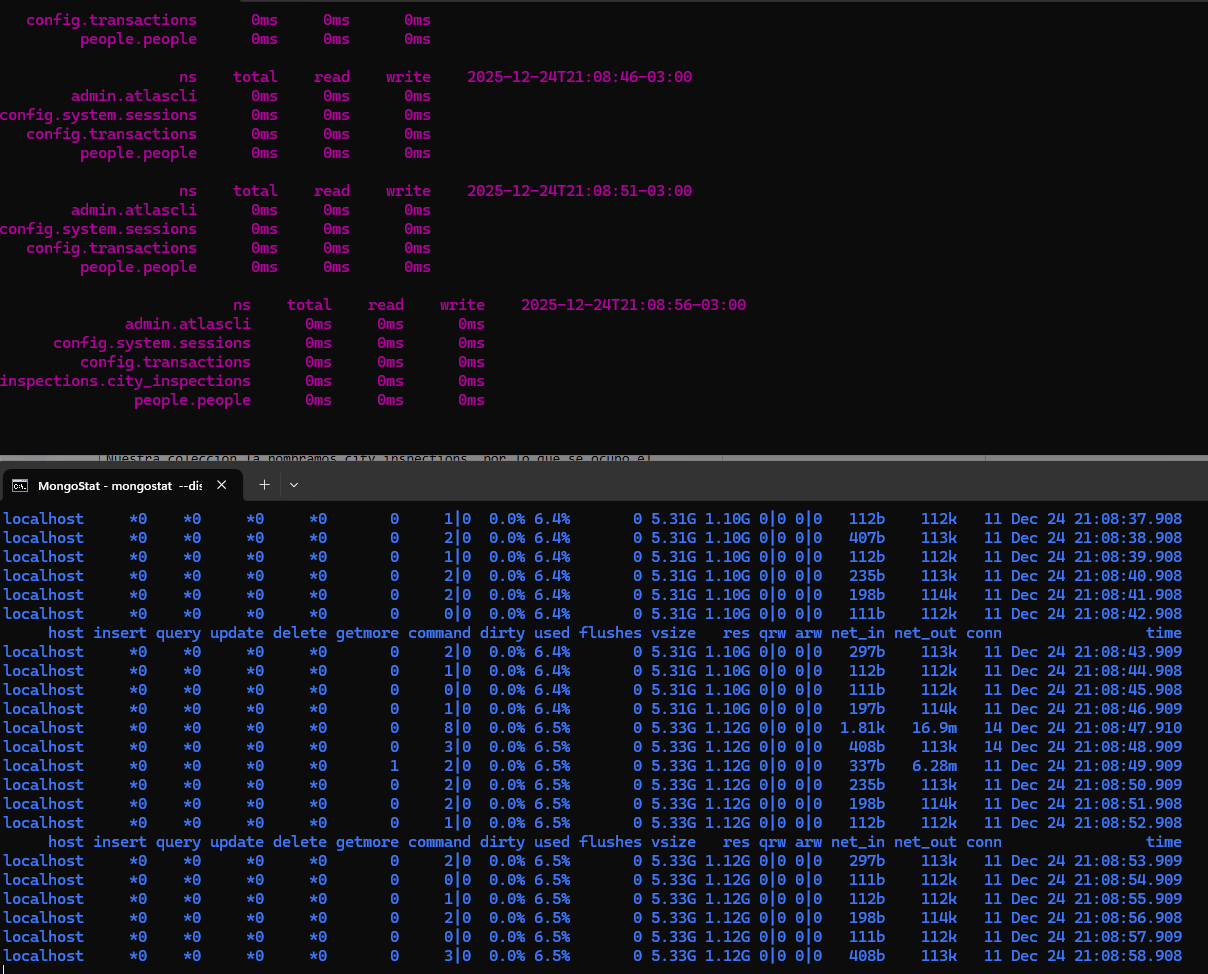


## **IV RESTAURAR UNA BASE DE DATOS**

En este apartado se entregan las siguientes instrucciones:

**a**. Para restaurar una base de datos, debéis indicar la ruta del directorio dump donde se almacenan los ficheros de la base de datos (json y bson).

>dump \
people\
--people.bson\
--people.metadata.json

**b**. Descomprimid el fichero act-grupal-people.zip y ubicad los ficheros en la estructura de directorios indicada en el paso anterior.



Nota: recordad el uso de la instrucción: mongorestore --port xxxxx PATH\dump


#### **Respuesta para puntos a y b**

Se realiza la estrutura de datos necesaria para la restauración de una base de datos utilizando la herramienta `mongorestore`.


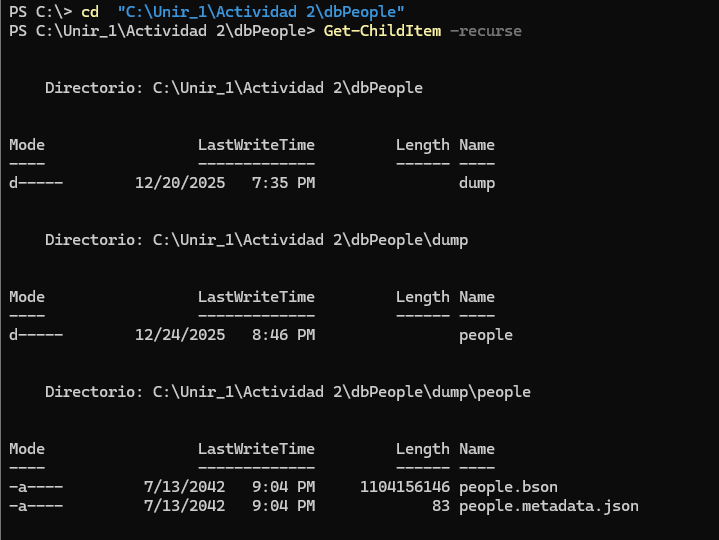


El uso de la herramienta de restauración necesita de los archivos de la carpeta dump que genera la herramienta de copias de seguridad mongodump. Esta acción se realizó en una maquina local, por lo que se utiliza el puerto por defecto que es el 27017 y se entrega el path de la copia de seguridad.

Script

`mongorestore --verbose --port 27017 "C:\Unir_1\Actividad 2\dbPeople\dump"`


.\
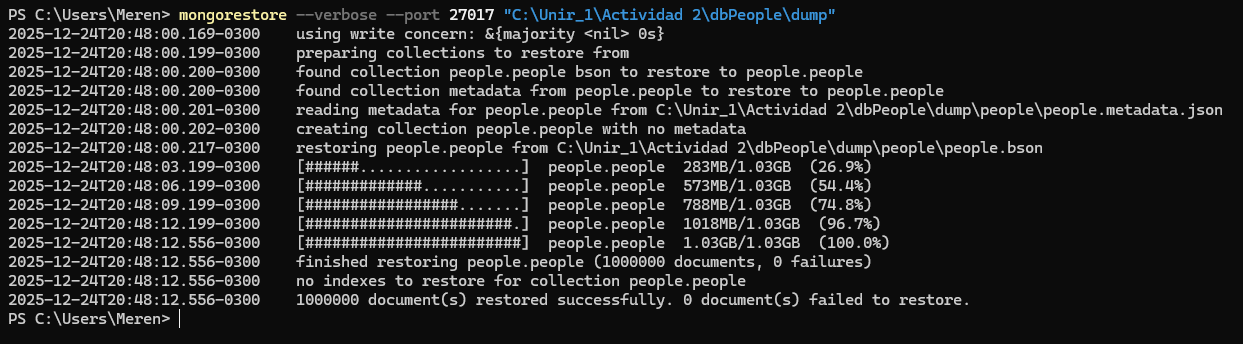  

.
Durante la restauración del servidor, se observó en la herramienta de monitorización de mongotop las escrituras que realizó el mongorestore. Por su parte mongostat detecto las escrituras `(insert)`, el aumento en el porcentaje de datos basura, `(dirty)` el aumento del uso de ram de 145M a 1.1G `(res)`, las variaciones en las cantidades de datos recibidos y enviados `(net_in y net_out)` y el aumento de conexiones al servidor de 11 a 14 por las herramientas.

.

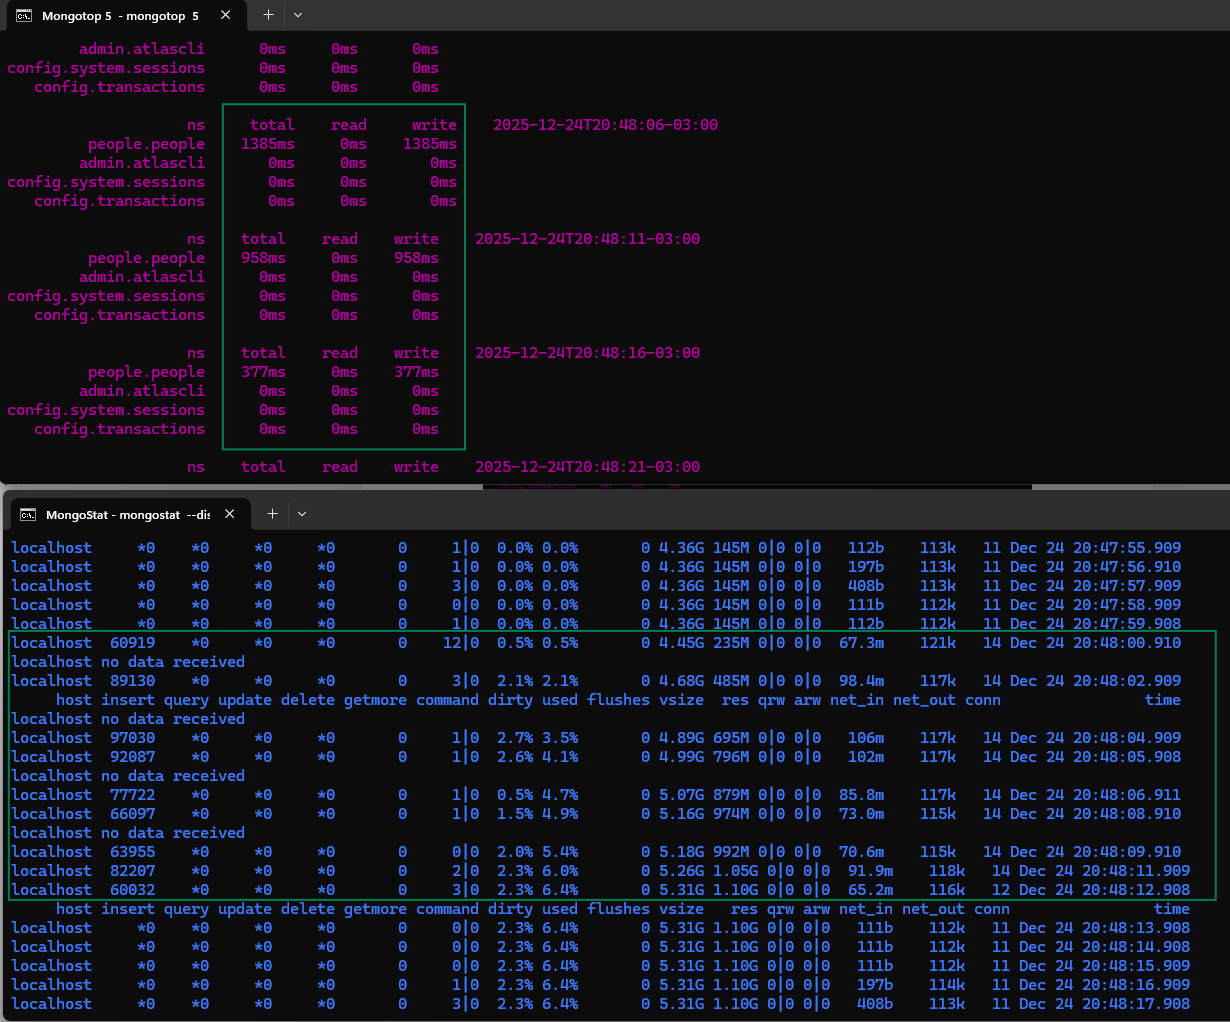

## **V. SEGUNDA PARTE**

## __Contexto del Caso de uso__

**Caso de uso**: restricción de terrazas en Madrid por covid-19.

 Contratan a nuestro equipo para actualizar las restricciones de ciertos locales y terrazas en Madrid por cuestiones del covid-19. Los datos para actualizar están en el fichero llamado act-grupal-openDataLocalesMadrid.cvs y se nos solicita que consolidemos dichos cambios en una base de datos MongoDB llamada Madrid con la colección Terrazas. La información del dataset a utilizar lo obtenemos en la siguiente [URL: Open Data Censo de locales, sus actividades y terrazas de hostelería y restauración (Terrazas)](https://datos.madrid.es/FWProjects/egob/Catalogo/Economia/Ficheros/Estructura_DS_FicheroCLA_Terrazas.pdf)

En el alcance del contrato se nos solicita:

a. Convertir el fichero CVS a formato JSON.\
b. Descargar el fichero generado en el paso anterior, en formato JSON indicando la opción Array. En el fichero hay un problema de espacios en muchos campos de tipo String, que se solicitan corregir en esta etapa.\
c. Editar el archivo generado, y al principio de todo añadir la línea: `var datos_insertar =`\
d. Guardar el fichero en una ruta conocida y cambiar su extensión a formato .js y explicar que tipo de fichero es un `.js`\
e. Abrir el cliente *mongo* y ejecutar las siguientes instrucciones:\
        `load("PATH\fichero.js")`\
        `datos_insertar[0]`\
f. Describir brevemente las instrucciones anteriores\
g. Se consulta si con el elemento: `datos_insertar ` ¿se podría realizar un ´insert´ masivo? ¿Cómo?\
h. Desde la terminar, nos solicitar proponer una alternativa que evite realizar los pasos anteriores, con una descripción de máximo de dos líneas.  

### **a. Convertir el fichero CVS a formato JSON**

En la actividad se solicita transformar el fichero CVS a JSON, utilizando como ejemplo la herramienta disponible en [https://csvjson.com/csv2json](https://csvjson.com/csv2json). Sin embargo esta herramienta no nos permite realizar limpiar la base de datos de los campos en blanco que tiene al final, ni de eliminar los espacios en blanco que hay en los datos de tipo string presentes en la base de datos, por lo realizaremos el siguiente flujo de trabajo antes de continuar con el paso c:

1. Subir archivo CVS al notebook desde el repo creado en GitHub.
2. Comprobar el número de filas y columnas del CVS
3. Homogenizar los títulos de las columnas
2. Limpiar CVS de los campos vacios al final de la DB utilizando Python y Pandas.
3. Limpiar los espacios entre los datos de tipo String presentes en la base de datos.
4. Revisar y cambiar los separadores de decimales presentes en la base de datos original y dejar el separador de decimales que lee MongoDB.
5. Convertir la base de datos a JSON para su lectura en MongoDB.

In [ ]:
# Importación de línbrerias
import pandas as pd
import numpy as np


In [ ]:
# Se leerá el CVS madrid
# El separador es (sep=;)
# Tomaremos todos los datos y forzaremos a pandas a que los lea como tipo "string" para no perder valores durante la lectura y posterior exportación.
# La lectura del CVS se realizará directamente desde el URL RAW definida a continuación:

url_csv = "https://raw.githubusercontent.com/Merenguimona/act_2/refs/heads/main/data/act-grupal-openDataLocalesMadrid.csv"

# Se crea la variable "madrid" como nombre de la base de datos con la colección terrazas en su interior.
#dtype=str -> todo se lee como texto
madrid = pd.read_csv(
    url_csv,
    sep=";",
    dtype=str
    )
# Se consultarán las primeras filas para verificar que se cargó bien el CVS
madrid.head()


,_id,id_local,id_distrito_local,desc_distrito_local,desc_barrio_local,clase_vial_edificio,num_edificio,Cod_Postal,coordenada_x_local,coordenada_y_local,...,sillas_es,sillas_ra,Unnamed: 36,Unnamed: 37,Unnamed: 38,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43
0,7,280067128,20,SAN BLAS-CANILLEJAS,ROSAS,CALLE,177,28022,"448900,55","4474755,41",...,10,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,32,270068967,4,SALAMANCA,RECOLETOS,CALLE,19,28001,"441830,59","4475475,52",...,20,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33,270403150,4,SALAMANCA,GUINDALERA,AVENIDA,2,28028,"442586,58","4476524,51",...,27,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,34,270078567,4,SALAMANCA,GUINDALERA,CALLE,25,28028,"442986,58","4476379,5",...,14,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,36,40002021,4,SALAMANCA,GUINDALERA,CALLE,10,28028,"442972,58","4476350,5",...,10,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Se comprueba que los datos no sean numéricos
madrid.dtypes

,0
_id,object
id_local,object
id_distrito_local,object
desc_distrito_local,object
desc_barrio_local,object
clase_vial_edificio,object
num_edificio,object
Cod_Postal,object
coordenada_x_local,object
coordenada_y_local,object


In [ ]:
#Comprobaciones
# filas y columnas del cvs
print("==== Número de (filas, columnas) ====")
print("            ",madrid.shape)
print("                                             ")
print("==== Columnas presentes en el CVS leído ====")
print("                                             ")
madrid.columns



==== Número de (filas, columnas) ====
             (2999, 44)
                                             
==== Columnas presentes en el CVS leído ====
                                             


Index(['_id', 'id_local', 'id_distrito_local', 'desc_distrito_local',
       'desc_barrio_local', 'clase_vial_edificio', 'num_edificio',
       'Cod_Postal', 'coordenada_x_local', 'coordenada_y_local',
       'desc_situacion_local', 'Nombre', 'id_periodo_terraza',
       'desc_periodo_terraza', 'id_situacion_terraza',
       'desc_situacion_terraza', 'Superficie_ES', 'DESC_CLASE', 'DESC_NOMBRE',
       'num_terraza', 'cal_terraza', 'desc_ubicacion_terraza',
       'hora_ini_LJ_es', 'hora_fin_LJ_es', 'hora_ini_LJ_ra', 'hora_fin_LJ_ra',
       'hora_ini_VS_es', 'hora_fin_VS_es', 'hora_ini_VS_ra', 'hora_fin_VS_ra',
       'mesas_aux_es', 'mesas_aux_ra', 'mesas_es', 'mesas_ra', 'sillas_es',
       'sillas_ra', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39',
       'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43'],
      dtype='object')

Al realizar las comprobaciones del archivo leído, observbamos que todos los datos han sido leídos como objetos, es decir no son de tipo numero, como integers o float, y que posee **2999 registros con 44 columnas**.

Además esta tabla posee final 8 columnas con el nombre de unnamed desde el 36 al 43. La explicación de la aparición de estas columnas esta dado por la fila con _id 2812, quien posee datos en estas ocho columnas sin título.

---
INSERTAR LA IMAGEN DEL EXCEL
---
---
Ante este error, se revisó el documento de la estructura del fichero y observamos que del total de 117 columnas y nuestro CVS posee 44. Por lo tanto, asumimos que estas últimas columnas poseen datos inutilizables y por ende se eliminarán de nuestro análisis.

---

**A continuación normalizaremos los nombres de los encabezados del CVS antes de su importación, para mantener su consistencia y no se generen errores por uso de mayúsculas o minúsculas**

In [ ]:
#Normalizaremos los nombres de las columnas, bajando todo el texto a minúsculas
madrid.columns = madrid.columns.str.strip().str.lower()

#Se verifica la normalización de los nombres
madrid.columns

Index(['_id', 'id_local', 'id_distrito_local', 'desc_distrito_local',
       'desc_barrio_local', 'clase_vial_edificio', 'num_edificio',
       'cod_postal', 'coordenada_x_local', 'coordenada_y_local',
       'desc_situacion_local', 'nombre', 'id_periodo_terraza',
       'desc_periodo_terraza', 'id_situacion_terraza',
       'desc_situacion_terraza', 'superficie_es', 'desc_clase', 'desc_nombre',
       'num_terraza', 'cal_terraza', 'desc_ubicacion_terraza',
       'hora_ini_lj_es', 'hora_fin_lj_es', 'hora_ini_lj_ra', 'hora_fin_lj_ra',
       'hora_ini_vs_es', 'hora_fin_vs_es', 'hora_ini_vs_ra', 'hora_fin_vs_ra',
       'mesas_aux_es', 'mesas_aux_ra', 'mesas_es', 'mesas_ra', 'sillas_es',
       'sillas_ra', 'unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39',
       'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43'],
      dtype='object')

**ELIMINACIÓN DE COLUMNAS FANTASMA**

En este punto, solicitaremos a python que recorra todos los nombres de las columnas, detectando cuales no tienen encabezado real, dado que pandas les asigno el nombre "unnamed". Estos nombres las guardaremos en una lista, la que posteriormente sea borrada.

In [ ]:
# Creación de la lista vacía para guardar los nombres de las columnas fantasma
# Al crear una lista, pandas nos permite borrar varias columnas a la vez si le
# entregamos la lista con sus nombres.

cols_fantasma =[]

#Recorremos uno por uno los nombres de las columnas del DataFrame

for c in madrid.columns:
     if c.startswith("unnamed"): #pandas llama a todas las columnas sin encabezado como "unnamed: x"
        cols_fantasma.append(c)

#Se realiza un print de lo que se encontro con ese nombre de inicio:
print("Columnas fantasmas detectadas:")
print(cols_fantasma)

Columnas fantasmas detectadas:
['unnamed: 36', 'unnamed: 37', 'unnamed: 38', 'unnamed: 39', 'unnamed: 40', 'unnamed: 41', 'unnamed: 42', 'unnamed: 43']


**Se confirma si las columnas poseen datos o no**


In [ ]:
if cols_fantasma:
    print("Cantidad de celdas con datos por columna fantasma:")
    print(madrid[cols_fantasma].notna().sum())


Cantidad de celdas con datos por columna fantasma:
unnamed: 36    1
unnamed: 37    1
unnamed: 38    1
unnamed: 39    1
unnamed: 40    1
unnamed: 41    1
unnamed: 42    1
unnamed: 43    1
dtype: int64


**Se confirma si la fila con datos corresponde al _id 2812 observada en el excel**

In [ ]:
# Creamos una máscara booleana:
# True en las filas donde AL MENOS una columna fantasma tiene datos
filas_con_datos_fantasma = madrid[cols_fantasma].notna().any(axis=1)


In [ ]:
# Número de filas con datos fantasma
filas_con_datos_fantasma.sum()

np.int64(1)

In [ ]:
# Mostramos el id y las columnas fantasma
madrid.loc[filas_con_datos_fantasma, ["_id"] + cols_fantasma]

,_id,unnamed: 36,unnamed: 37,unnamed: 38,unnamed: 39,unnamed: 40,unnamed: 41,unnamed: 42,unnamed: 43
1822,2812,10:00:00,0:00:00,0,0,16,16,64,


Con estos datos corroboramos que lo observado en el excel es consistente con lo observado con pandas. Ante esto se procederá a borrar las columnas fantasma.